In [2]:
import os
import pandas as pd

from pathlib import Path

from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import explode

DATASET_DIR = Path('./datasets/otto-recommender-system')
TRAIN_JSON = DATASET_DIR / 'train.jsonl'
TEST_JSON = DATASET_DIR / 'test.jsonl'
TRAIN_PARQUET = DATASET_DIR / 'train.parquet'
TEST_PARQUET = DATASET_DIR / 'test.parquet'

In [3]:
# load env
load_dotenv()

True

In [4]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("EDA")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
	.config('spark.sql.execution.arrow.pyspark.enabled', 'true')
    .config("spark.sql.files.maxPartitionBytes", "32m")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/08 14:40:59 WARN Utils: Your hostname, KieuHongPhong, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/03/08 14:40:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/08 14:41:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [ ]:
# def json_to_parquet(file_path, output_path):
# 	df = spark.read.json(file_path)
# 	df.write.parquet(output_path, mode="overwrite")
# 	print(f'Converted {file_path} to {output_path}')

# json_to_parquet(
# 	str(TRAIN_JSON),
# 	str(TRAIN_PARQUET)
# )

# json_to_parquet(
# 	str(TEST_JSON), str(TEST_PARQUET)
# )

Converted datasets/otto-recommender-system/train.jsonl to datasets/otto-recommender-system/train.parquet


Converted datasets/otto-recommender-system/test.jsonl to datasets/otto-recommender-system/test.parquet


In [4]:
# Load parquet file
train_df = spark.read.parquet(str(TRAIN_PARQUET))

In [5]:
train_df.printSchema()

root
 |-- _corrupt_record: string (nullable = true)
 |-- events: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- aid: long (nullable = true)
 |    |    |-- ts: long (nullable = true)
 |    |    |-- type: string (nullable = true)
 |-- session: long (nullable = true)



In [9]:
df2 = train_df.select("session", explode("events").alias("event"))
df3 = df2.select("session", "event.aid", "event.ts", "event.type")
df3.show(3)

+-------+-------+-------------+------+
|session|    aid|           ts|  type|
+-------+-------+-------------+------+
|4194457| 368042|1659726203726|clicks|
|4194457| 368042|1659726221720| carts|
|4194457|1677366|1659726283361|clicks|
+-------+-------+-------------+------+
only showing top 3 rows


In [11]:
# Count sessions in train_df
session_count = train_df.select("session").distinct().count()
print(f"Number of sessions in train_df: {session_count:,}")

Number of sessions in train_df: 9,717,858


In [12]:
# Check if there are any new items in the test set that not in train_df
test_df = spark.read.parquet(str(TEST_PARQUET))
train_aids = set(train_df.select(explode("events.aid").alias("aid")).distinct().rdd.flatMap(lambda x: x).collect())
test_aids = set(test_df.select(explode("events.aid").alias("aid")).distinct().rdd.flatMap(lambda x: x).collect())
new_aids_in_test = test_aids - train_aids
print(f"Number of new items in test set: {len(new_aids_in_test)}")

Number of new items in test set: 468


In [18]:
from pyspark.sql import functions as F
from pyspark.sql.types import LongType

OUTPUT_DIR   = DATASET_DIR / 'splits'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


df = spark.read.parquet(str(TRAIN_PARQUET))

df = df.withColumn("first_ts", F.col("events")[0]["ts"])

WEEK_MS = 7 * 24 * 60 * 60 * 1000 

stats = df.selectExpr("min(first_ts) as min_ts", "max(first_ts) as max_ts").first()
min_ts, max_ts = stats["min_ts"], stats["max_ts"]

print(f"Data range : {min_ts} → {max_ts}")
print(f"Weeks span : {(max_ts - min_ts) / WEEK_MS:.2f} weeks")

df = df.withColumn(
    "week_num",
    ((F.col("first_ts") - F.lit(min_ts)) / F.lit(WEEK_MS)).cast(LongType())
)

# Kiểm tra phân bố sessions theo tuần
print("\nSession count per week:")
df.groupBy("week_num").count().orderBy("week_num").show()

# Split: 3 tuần đầu = train, tuần cuối = validate 
max_week = df.selectExpr("max(week_num) as max_week").first()["max_week"]
print(f"Max week: {max_week}  →  train=week 0~{max_week-1}, validate=week {max_week}")

train_df    = df.filter(F.col("week_num") <  max_week).drop("first_ts", "week_num")
validate_df = df.filter(F.col("week_num") == max_week).drop("first_ts", "week_num")

print(f"\nTrain    : {train_df.count():,} sessions")
print(f"Validate : {validate_df.count():,} sessions")

# ── 5. Save ────────────────────────────────────────────────────────────────────
TRAIN_OUT    = str(OUTPUT_DIR / 'train_weeks_1_3.parquet')
VALIDATE_OUT = str(OUTPUT_DIR / 'validate_week_last.parquet')

train_df.write.mode("overwrite").parquet(TRAIN_OUT)
validate_df.write.mode("overwrite").parquet(VALIDATE_OUT)

print(f"\nSaved train    → {TRAIN_OUT}")
print(f"Saved validate → {VALIDATE_OUT}")

Data range : 1659304800025 → 1660756234211
Weeks span : 2.40 weeks

Session count per week:


+--------+-------+
|week_num|  count|
+--------+-------+
|    NULL|      1|
|       0|5348783|
|       1|3294437|
|       2|1074637|
+--------+-------+



Max week: 2  →  train=week 0~1, validate=week 2



Train    : 8,643,220 sessions


Validate : 1,074,637 sessions



Saved train    → datasets/otto-recommender-system/splits/train_weeks_1_3.parquet
Saved validate → datasets/otto-recommender-system/splits/validate_week_last.parquet


In [19]:
from pyspark.sql.functions import explode, col, array_distinct

# Load lại splits đã lưu
train_df    = spark.read.parquet(str(OUTPUT_DIR / 'train_weeks_1_3.parquet'))
validate_df = spark.read.parquet(str(OUTPUT_DIR / 'validate_week_last.parquet'))

train_aids = (
    train_df
    .select(explode("events").alias("event"))
    .select(col("event.aid").alias("aid"))
    .distinct()
)

validate_aids = (
    validate_df
    .select(explode("events").alias("event"))
    .select(col("event.aid").alias("aid"))
    .distinct()
)

# Sản phẩm xuất hiện trong week 3 nhưng KHÔNG có trong week 0-2
new_aids = validate_aids.subtract(train_aids)

total_validate_aids = validate_aids.count()
total_train_aids    = train_aids.count()
total_new_aids      = new_aids.count()

print(f"Unique AIDs trong train (week 0-2) : {total_train_aids:,}")
print(f"Unique AIDs trong validate (week 3): {total_validate_aids:,}")
print(f"AIDs mới trong week 3 (cold items)  : {total_new_aids:,}")
print(f"Tỷ lệ cold items                    : {total_new_aids/total_validate_aids*100:.2f}%")

# Xem thử vài sản phẩm mới
print("\nVí dụ 10 cold items:")
new_aids.show(10)

Unique AIDs trong train (week 0-2) : 1,850,522
Unique AIDs trong validate (week 3): 1,035,853
AIDs mới trong week 3 (cold items)  : 1,968
Tỷ lệ cold items                    : 0.19%

Ví dụ 10 cold items:


+------+
|   aid|
+------+
| 68310|
| 78533|
|135778|
|203455|
|227561|
|283335|
|331289|
|396291|
|456487|
|472823|
+------+
only showing top 10 rows


26/03/08 14:52:08 WARN MemoryStore: Not enough space to cache rdd_22_6 in memory! (computed 31.5 MiB so far)
26/03/08 14:52:08 WARN MemoryStore: Not enough space to cache rdd_22_5 in memory! (computed 20.0 MiB so far)
26/03/08 14:52:10 WARN MemoryStore: Not enough space to cache rdd_22_7 in memory! (computed 31.3 MiB so far)
26/03/08 14:52:18 WARN MemoryStore: Not enough space to cache rdd_22_10 in memory! (computed 31.2 MiB so far)
26/03/08 14:52:36 WARN MemoryStore: Not enough space to cache rdd_22_13 in memory! (computed 20.1 MiB so far)
26/03/08 14:52:37 WARN MemoryStore: Not enough space to cache rdd_22_12 in memory! (computed 31.3 MiB so far)
26/03/08 14:53:07 WARN MemoryStore: Not enough space to cache rdd_22_17 in memory! (computed 31.2 MiB so far)
26/03/08 14:53:25 WARN MemoryStore: Not enough space to cache rdd_22_21 in memory! (computed 20.0 MiB so far)
26/03/08 14:54:01 WARN MemoryStore: Not enough space to cache rdd_22_20 in memory! (computed 19.7 MiB so far)
26/03/08 14:5

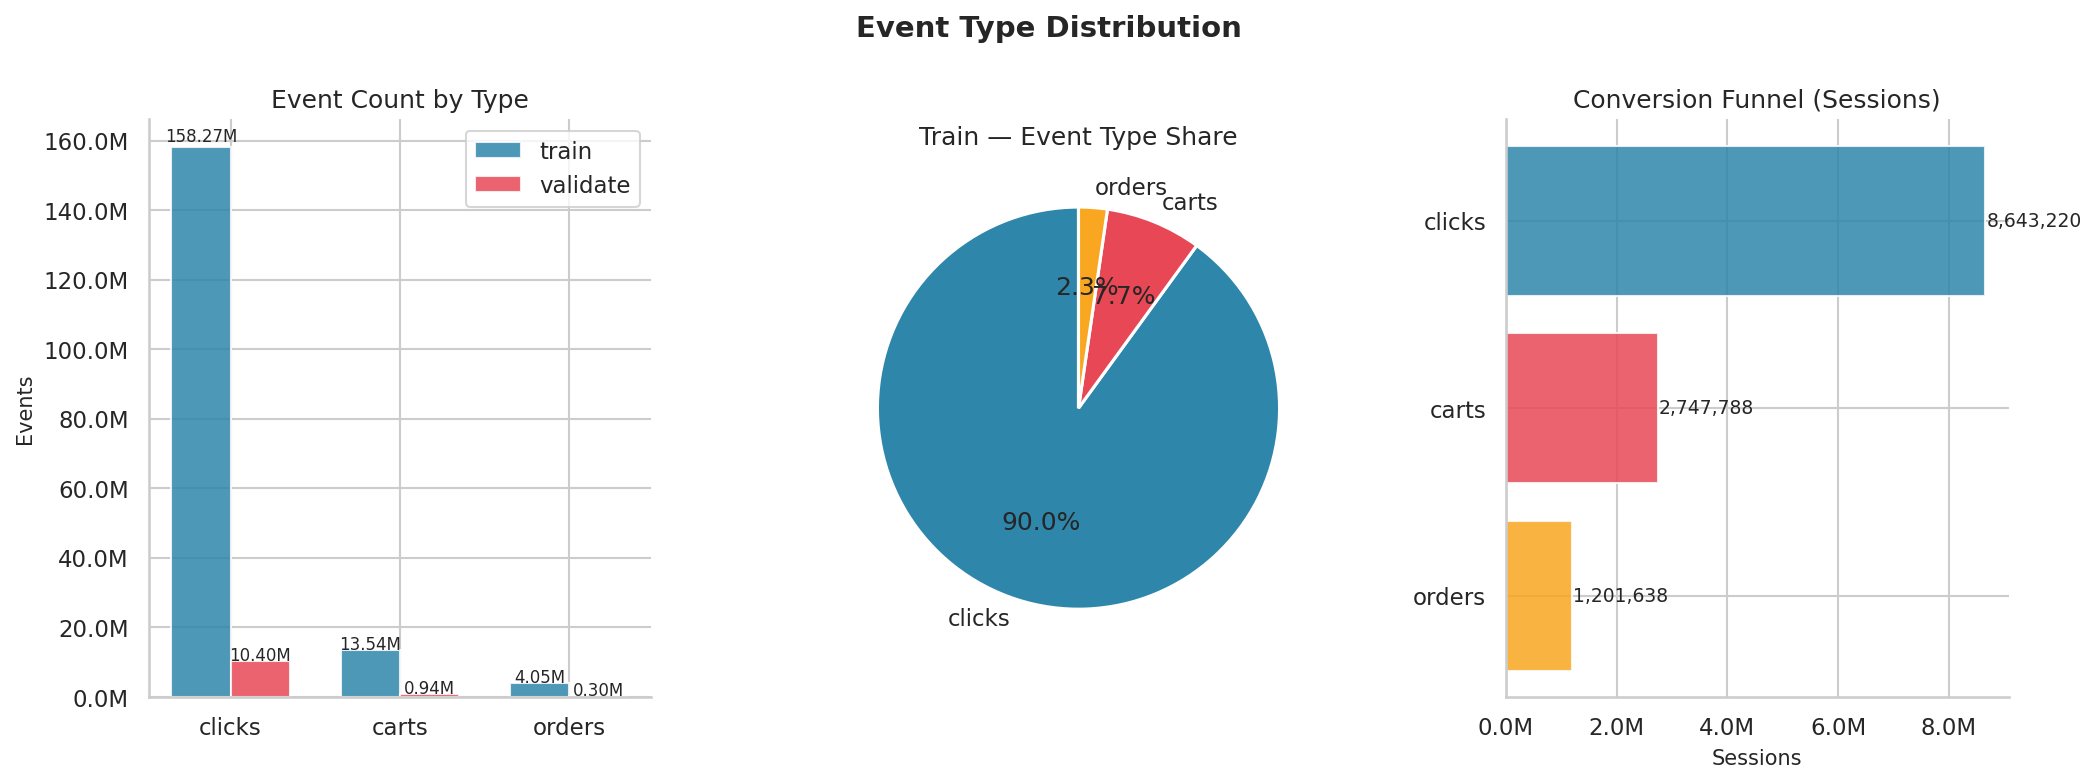


[Event Type Stats]
split       train  validate
type                       
carts    13544389    935273
clicks  158268702  10399901
orders    4051744    298142


[1930.180s][warning][gc,alloc] shuffle-client-5-1: Retried waiting for GCLocker too often allocating 5530469 words


26/03/08 15:12:17 WARN BlockManager: Failed to fetch remote block taskresult_303 from [BlockManagerId(driver, 10.255.255.254, 46641, None)] after 1 fetch failures. Most recent failure cause:
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.network.BlockTransferService.fetchBlockSync(BlockTransferService.scala:103)
	at org.apache.spark.storage.BlockManager.fetchRemoteManagedBuffer(BlockManager.scala:1208)
	at org.apache.spark.storage.BlockManager.$anonfun$getRemoteBlock$8(BlockManager.scala:1152)
	at scala.Option.orElse(Option.scala:477)
	at org.apache.spark.storage.BlockManager.getRemoteBlock(BlockManager.scala:1152)
	at org.apache.spark.storage.BlockManager.getRemoteBytes(BlockManager.scala:1295)
	at org.apache.spark.scheduler.TaskResultGetter$$anon$3.$anonfun$run$1(TaskResultGetter.scala:89)

Py4JJavaError: An error occurred while calling o193.getResult.
: org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:126)
	at org.apache.spark.security.SocketAuthServer.getResult(SocketAuthServer.scala:122)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:77)
	at java.base/jdk.internal.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
	at java.base/java.lang.reflect.Method.invoke(Method.java:569)
	at py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
	at py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:374)
	at py4j.Gateway.invoke(Gateway.java:282)
	at py4

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from pyspark.sql import functions as F
from pyspark.sql.functions import explode, col, count, countDistinct, avg
from pyspark.sql.window import Window

DATASET_DIR = Path('./datasets/otto-recommender-system')
OUTPUT_DIR  = DATASET_DIR / 'splits'
PLOT_DIR    = Path('./plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE     = ["#2E86AB", "#E84855", "#F9A620"]
TYPE_ORDER  = ["clicks", "carts", "orders"]
TYPE_COLOR  = dict(zip(TYPE_ORDER, PALETTE))

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update({
    "figure.dpi"       : 150,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.titlesize"   : 12,
    "axes.labelsize"   : 10,
})

train_df    = spark.read.parquet(str(OUTPUT_DIR / 'train_weeks_1_3.parquet'))
validate_df = spark.read.parquet(str(OUTPUT_DIR / 'validate_week_last.parquet'))

def explode_events(df, label):
    return (
        df.select("session", explode("events").alias("e"))
          .select(
              col("session"),
              col("e.ts").alias("ts"),
              col("e.aid").alias("aid"),
              col("e.type").alias("type"),
          )
          .withColumn("split", F.lit(label))
    )

train_flat = explode_events(train_df, "train").cache()
val_flat   = explode_events(validate_df, "validate").cache()
all_flat   = train_flat.union(val_flat).cache()


# ==============================================================================
# 1. EVENT TYPE DISTRIBUTION
# ==============================================================================
type_dist = (
    all_flat
    .groupBy("split", "type")
    .agg(count("*").alias("n"))
    .toPandas()
)

train_type = type_dist[type_dist["split"] == "train"].set_index("type").reindex(TYPE_ORDER)
val_type   = type_dist[type_dist["split"] == "validate"].set_index("type").reindex(TYPE_ORDER)

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs[0])
x   = np.arange(len(TYPE_ORDER))
w   = 0.35
b1  = ax0.bar(x - w/2, train_type["n"], w, label="train",    color=PALETTE[0], alpha=0.85)
b2  = ax0.bar(x + w/2, val_type["n"],   w, label="validate", color=PALETTE[1], alpha=0.85)
ax0.set_xticks(x); ax0.set_xticklabels(TYPE_ORDER)
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax0.set_title("Event Count by Type"); ax0.set_ylabel("Events")
ax0.legend()
for bar in list(b1) + list(b2):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e6:.2f}M", ha="center", fontsize=8)

ax1 = fig.add_subplot(gs[1])
ax1.pie(train_type["n"], labels=TYPE_ORDER, autopct="%1.1f%%",
        colors=PALETTE, startangle=90, wedgeprops=dict(edgecolor="white", linewidth=1.5))
ax1.set_title("Train — Event Type Share")

ax2 = fig.add_subplot(gs[2])
funnel_sessions = (
    train_flat
    .groupBy("session", "type").agg(count("*").alias("n"))
    .groupBy("type").agg(countDistinct("session").alias("sessions"))
    .toPandas()
    .set_index("type").reindex(TYPE_ORDER)
)
bars = ax2.barh(TYPE_ORDER[::-1], funnel_sessions["sessions"][::-1],
                color=PALETTE[::-1], alpha=0.85, edgecolor="white")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
ax2.set_title("Conversion Funnel (Sessions)")
ax2.set_xlabel("Sessions")
for bar, val in zip(bars, funnel_sessions["sessions"][::-1]):
    ax2.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

fig.suptitle("Event Type Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.savefig(PLOT_DIR / "1_event_types.png", bbox_inches="tight")
plt.show()

print("\n[Event Type Stats]")
print(type_dist.pivot(index="type", columns="split", values="n"))


# ==============================================================================
# 2. SESSION ANALYSIS
# ==============================================================================
sess_stats = (
    train_flat
    .groupBy("session")
    .agg(
        count("*").alias("n_events"),
        countDistinct("aid").alias("n_unique_aids"),
        countDistinct("type").alias("n_types"),
        ((F.max("ts") - F.min("ts")) / 1000 / 60).alias("duration_min"),
    )
    .toPandas()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Session Analysis", fontsize=14, fontweight="bold")

def hist(ax, data, clip, bins, color, title, xlabel):
    ax.hist(data.clip(upper=clip), bins=bins, color=color, edgecolor="white", linewidth=0.4)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("Sessions")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
    med = data.median()
    ax.axvline(med, color="red", linestyle="--", linewidth=1.2, label=f"median={med:.1f}")
    ax.legend(fontsize=9)

hist(axes[0,0], sess_stats["n_events"],      50,  50, PALETTE[0], "Events per Session (clip@50)",          "# events")
hist(axes[0,1], sess_stats["n_unique_aids"],  30,  30, PALETTE[1], "Unique Items per Session (clip@30)",    "# unique AIDs")
hist(axes[0,2], sess_stats["duration_min"],  120,  60, PALETTE[2], "Session Duration (clip@120 min)",       "minutes")

axes[1,0].scatter(
    sess_stats["duration_min"].clip(upper=120),
    sess_stats["n_events"].clip(upper=50),
    alpha=0.15, s=4, color=PALETTE[0]
)
axes[1,0].set_title("Duration vs Events per Session")
axes[1,0].set_xlabel("Duration (min)"); axes[1,0].set_ylabel("# events")

type_counts_per_sess = (
    train_flat.groupBy("session", "type").agg(count("*").alias("n")).toPandas()
)
sns.boxplot(
    data=type_counts_per_sess, x="type", y="n", order=TYPE_ORDER,
    palette=TYPE_COLOR, ax=axes[1,1],
    showfliers=False
)
axes[1,1].set_title("Events per Session by Type (no outliers)")
axes[1,1].set_xlabel("Event type"); axes[1,1].set_ylabel("# events")

type_share = sess_stats["n_types"].value_counts().sort_index()
axes[1,2].bar(type_share.index.astype(str), type_share.values,
              color=PALETTE[0], edgecolor="white", alpha=0.85)
axes[1,2].set_title("# Distinct Event Types per Session")
axes[1,2].set_xlabel("# types (1=only clicks, 3=all types)")
axes[1,2].set_ylabel("# sessions")
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))

plt.tight_layout()
plt.savefig(PLOT_DIR / "2_sessions.png", bbox_inches="tight")
plt.show()

print("\n[Session Stats]")
print(sess_stats[["n_events","n_unique_aids","duration_min"]].describe().round(2))


# ==============================================================================
# 3. ITEM POPULARITY (LONG-TAIL)
# ==============================================================================
item_freq = (
    train_flat
    .groupBy("aid", "type")
    .agg(count("*").alias("n"))
    .toPandas()
)
item_total = (
    item_freq.groupby("aid")["n"].sum()
    .reset_index().sort_values("n", ascending=False)
    .reset_index(drop=True)
)
item_total["rank"]    = np.arange(1, len(item_total) + 1)
item_total["cum_pct"] = item_total["n"].cumsum() / item_total["n"].sum() * 100

top20_threshold = item_total[item_total["cum_pct"] <= 20]["rank"].max()
top50_threshold = item_total[item_total["cum_pct"] <= 50]["rank"].max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Item Popularity", fontsize=14, fontweight="bold")

axes[0].loglog(item_total["rank"], item_total["n"], lw=1.5, color=PALETTE[0], alpha=0.9)
axes[0].axvline(top20_threshold, color="red",    linestyle="--", linewidth=1,
                label=f"20% coverage (@rank {top20_threshold:,})")
axes[0].axvline(top50_threshold, color="orange", linestyle="--", linewidth=1,
                label=f"50% coverage (@rank {top50_threshold:,})")
axes[0].set_title("Rank vs Frequency (Log-Log)")
axes[0].set_xlabel("Item Rank"); axes[0].set_ylabel("# Interactions")
axes[0].legend(fontsize=8)

axes[1].plot(item_total["rank"], item_total["cum_pct"], lw=2, color=PALETTE[1])
axes[1].axhline(80, color="red",    linestyle="--", linewidth=1, label="80%")
axes[1].axhline(50, color="orange", linestyle="--", linewidth=1, label="50%")
axes[1].set_title("Cumulative Coverage by Item Rank")
axes[1].set_xlabel("Item Rank"); axes[1].set_ylabel("Cumulative %")
axes[1].legend()

n_items = len(item_total)
buckets = pd.cut(
    item_total["rank"],
    bins=[0, n_items*0.01, n_items*0.1, n_items*0.5, n_items],
    labels=["Top 1%", "1-10%", "10-50%", "Bottom 50%"]
)
bucket_share = item_total.groupby(buckets, observed=True)["n"].sum()
bucket_pct   = bucket_share / bucket_share.sum() * 100
axes[2].bar(bucket_pct.index, bucket_pct.values,
            color=PALETTE + ["#AAAAAA"], edgecolor="white", alpha=0.85)
axes[2].set_title("Interaction Share by Popularity Tier")
axes[2].set_ylabel("% of total interactions")
for i, (idx, val) in enumerate(bucket_pct.items()):
    axes[2].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(PLOT_DIR / "3_item_popularity.png", bbox_inches="tight")
plt.show()

total_items = n_items
print(f"\n[Item Popularity]")
print(f"  Total unique items : {total_items:,}")
print(f"  Top 1% items cover : {bucket_pct.iloc[0]:.1f}% of interactions")
print(f"  20% coverage at rank: {top20_threshold:,} ({top20_threshold/total_items*100:.1f}% of catalog)")
print(f"  50% coverage at rank: {top50_threshold:,} ({top50_threshold/total_items*100:.1f}% of catalog)")


# ==============================================================================
# 4. HOT ITEMS (Top items per event type)
# ==============================================================================
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f"Top {TOP_N} Hot Items by Event Type (Train)", fontsize=14, fontweight="bold")

for ax, etype in zip(axes, TYPE_ORDER):
    sub = (
        item_freq[item_freq["type"] == etype]
        .sort_values("n", ascending=False)
        .head(TOP_N)
        .reset_index(drop=True)
    )
    sub["aid_str"] = sub["aid"].astype(str)

    bars = ax.barh(sub["aid_str"][::-1], sub["n"][::-1],
                   color=TYPE_COLOR[etype], alpha=0.85, edgecolor="white")
    ax.set_title(f"{etype.capitalize()} — Top {TOP_N}")
    ax.set_xlabel("# events")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
    for bar, val in zip(bars, sub["n"][::-1]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(PLOT_DIR / "4_hot_items.png", bbox_inches="tight")
plt.show()

print(f"\n[Hot Items — Top 5 per type]")
for etype in TYPE_ORDER:
    top5 = item_freq[item_freq["type"] == etype].nlargest(5, "n")[["aid","n"]]
    print(f"\n  {etype}:")
    print(top5.to_string(index=False))